In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM, Conv1D, GlobalMaxPooling1D, Dense, Dropout

from helper_baseline import *
from plots import *
from keras_helper import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = pd.read_csv('yelp.csv')

In [3]:
df = df.drop_duplicates()
df['text_clean'] = df['text'].apply(clean_text)

X_text = df['text_clean'].values
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# train
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')

# test
X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [40]:
RNN_scores = train_model_cv('rnn', X_train, y_train, MAX_WORDS, MAX_LEN, 0.001)

Fold 1
Epoch 1/30


d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5739 - loss: 0.6861 - val_accuracy: 0.5940 - val_loss: 0.6760
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5790 - loss: 0.6826 - val_accuracy: 0.5940 - val_loss: 0.6861
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5810 - loss: 0.6829 - val_accuracy: 0.5940 - val_loss: 0.6704
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5978 - loss: 0.6767 - val_accuracy: 0.6474 - val_loss: 0.6505
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6517 - loss: 0.6513 - val_accuracy: 0.6649 - val_loss: 0.6371
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6489 - loss: 0.6503 - val_accuracy: 0.6510 - val_loss: 0.6441
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6118 - loss: 0.6612 - val_accuracy: 0.5225 - val_loss: 0.6922
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5753 - loss: 0.6820 - val_accuracy: 0.594

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5703 - loss: 0.6869 - val_accuracy: 0.5940 - val_loss: 0.6870
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5838 - loss: 0.6823 - val_accuracy: 0.5940 - val_loss: 0.6795
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5643 - loss: 0.6908 - val_accuracy: 0.5940 - val_loss: 0.6696
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5748 - loss: 0.6833 - val_accuracy: 0.5870 - val_loss: 0.6735
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5888 - loss: 0.6725 - val_accuracy: 0.5940 - val_loss: 0.6712
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6754 - loss: 0.6069 - val_accuracy: 0.7116 - val_loss: 0.5840
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7636 - loss: 0.5225 - val_accuracy: 0.7394 - val_loss: 0.5365
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8006 - loss: 0.4626 - val_accuracy: 0.734

...

415/415 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6738 - loss: 0.6134 - val_accuracy: 0.7028 - val_loss: 0.5696
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7483 - loss: 0.5304 - val_accuracy: 0.8150 - val_loss: 0.4416
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8699 - loss: 0.3472 - val_accuracy: 0.8672 - val_loss: 0.3359
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8484 - loss: 0.3427 - val_accuracy: 0.5941 - val_loss: 0.6760
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5578 - loss: 0.7014 - val_accuracy: 0.5941 - val_loss: 0.6752
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7187 - loss: 0.5714 - val_accuracy: 0.7661 - val_loss: 0.5470
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8077 - loss: 0.4937 - val_accuracy: 0.7809 - val_loss: 0.5284
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7475 - loss: 0.5571 - val_accuracy: 0.641

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6027 - loss: 0.6657 - val_accuracy: 0.6865 - val_loss: 0.6152
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7576 - loss: 0.5230 - val_accuracy: 0.8150 - val_loss: 0.4442
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7395 - loss: 0.5338 - val_accuracy: 0.5941 - val_loss: 0.6764
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5789 - loss: 0.6835 - val_accuracy: 0.5941 - val_loss: 0.6753
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5886 - loss: 0.6799 - val_accuracy: 0.5941 - val_loss: 0.6621
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5913 - loss: 0.6792 - val_accuracy: 0.5941 - val_loss: 0.6772
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7238 - loss: 0.5418 - val_accuracy: 0.8361 - val_loss: 0.3937
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8672 - loss: 0.3417 - val_accuracy: 0.860

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6272 - loss: 0.6454 - val_accuracy: 0.7752 - val_loss: 0.5055
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6165 - loss: 0.6543 - val_accuracy: 0.5966 - val_loss: 0.6663
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7218 - loss: 0.5724 - val_accuracy: 0.7677 - val_loss: 0.5096
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8004 - loss: 0.4650 - val_accuracy: 0.7646 - val_loss: 0.5182
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6272 - loss: 0.6292 - val_accuracy: 0.5984 - val_loss: 0.6551
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5833 - loss: 0.6717 - val_accuracy: 0.5941 - val_loss: 0.6621
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6562 - loss: 0.6065 - val_accuracy: 0.6608 - val_loss: 0.6205
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6812 - loss: 0.5883 - val_accuracy: 0.623

In [42]:
final_model_rnn = build_model('rnn', MAX_WORDS, MAX_LEN, 0.001)

final_model_rnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    verbose=0
)

y_test_proba = final_model_rnn.predict(X_test).ravel()
y_test_pred = (y_test_proba > 0.5).astype(int)

print("\n📊 Test Results (RNN):")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

📊 Test Results (RNN):
Accuracy: 0.6988
Precision: 0.7629
Recall: 0.7152
F1-score: 0.7383
ROC-AUC: 0.7658


In [5]:
LSTM_scores = train_model_cv('lstm', X_train, y_train, MAX_WORDS, MAX_LEN, 0.001)

Fold 1
Epoch 1/30


d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8531 - loss: 0.3376 - val_accuracy: 0.9339 - val_loss: 0.1763
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9596 - loss: 0.1152 - val_accuracy: 0.9388 - val_loss: 0.1590
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9760 - loss: 0.0741 - val_accuracy: 0.9379 - val_loss: 0.1727
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9831 - loss: 0.0502 - val_accuracy: 0.9345 - val_loss: 0.1919
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9876 - loss: 0.0390 - val_accuracy: 0.9300 - val_loss: 0.2170
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9900 - loss: 0.0314 - val_accuracy: 0.9321 - val_loss: 0.2279
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9924 - loss: 0.0233 - val_accuracy: 0.9330 - val_loss: 0.2422
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9943 - loss: 0.0196 - val_accurac

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7939 - loss: 0.4363 - val_accuracy: 0.9167 - val_loss: 0.2153
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9415 - loss: 0.1575 - val_accuracy: 0.9379 - val_loss: 0.1712
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9712 - loss: 0.0891 - val_accuracy: 0.9451 - val_loss: 0.1619
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9810 - loss: 0.0629 - val_accuracy: 0.9442 - val_loss: 0.1742
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9846 - loss: 0.0486 - val_accuracy: 0.9445 - val_loss: 0.1824
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9888 - loss: 0.0364 - val_accuracy: 0.9415 - val_loss: 0.2067
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9853 - loss: 0.0474 - val_accuracy: 0.9348 - val_loss: 0.2254
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9865 - loss: 0.0420 - val_accurac

...

415/415 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8395 - loss: 0.3416 - val_accuracy: 0.9381 - val_loss: 0.1642
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9588 - loss: 0.1204 - val_accuracy: 0.9499 - val_loss: 0.1378
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9765 - loss: 0.0742 - val_accuracy: 0.9463 - val_loss: 0.1371
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9842 - loss: 0.0511 - val_accuracy: 0.9378 - val_loss: 0.1834
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9888 - loss: 0.0384 - val_accuracy: 0.9469 - val_loss: 0.1624
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9906 - loss: 0.0307 - val_accuracy: 0.9460 - val_loss: 0.1682
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9913 - loss: 0.0298 - val_accuracy: 0.9436 - val_loss: 0.2031
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9928 - loss: 0.0245 - val_accurac

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8272 - loss: 0.3789 - val_accuracy: 0.9179 - val_loss: 0.1926
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9547 - loss: 0.1285 - val_accuracy: 0.9406 - val_loss: 0.1623
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9733 - loss: 0.0809 - val_accuracy: 0.9357 - val_loss: 0.1885
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9817 - loss: 0.0578 - val_accuracy: 0.9372 - val_loss: 0.1891
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9870 - loss: 0.0442 - val_accuracy: 0.9403 - val_loss: 0.1947
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9886 - loss: 0.0389 - val_accuracy: 0.9378 - val_loss: 0.2159
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9878 - loss: 0.0398 - val_accuracy: 0.9345 - val_loss: 0.2416
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9919 - loss: 0.0270 - val_accurac

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8369 - loss: 0.3408 - val_accuracy: 0.9306 - val_loss: 0.1797
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9576 - loss: 0.1187 - val_accuracy: 0.9345 - val_loss: 0.1681
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9769 - loss: 0.0698 - val_accuracy: 0.9378 - val_loss: 0.1691
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9814 - loss: 0.0531 - val_accuracy: 0.9378 - val_loss: 0.1832
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9859 - loss: 0.0457 - val_accuracy: 0.9357 - val_loss: 0.2072
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9889 - loss: 0.0340 - val_accuracy: 0.9396 - val_loss: 0.2035
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9917 - loss: 0.0273 - val_accuracy: 0.9357 - val_loss: 0.2232
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9928 - loss: 0.0229 - val_accurac

In [6]:
final_model_lstm = build_model('lstm', MAX_WORDS, MAX_LEN, 0.001)

final_model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    verbose=0
)

y_test_proba = final_model_lstm.predict(X_test).ravel()
y_test_pred = (y_test_proba > 0.5).astype(int)

print("\n📊 Test Results (LSTM):")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

📊 Test Results (LSTM):
Accuracy: 0.9293
Precision: 0.9407
Recall: 0.9403
F1-score: 0.9405
ROC-AUC: 0.9786


In [7]:
CNN_scores = train_model_cv('cnn', X_train, y_train, MAX_WORDS, MAX_LEN, 0.001)

Fold 1
Epoch 1/30


d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8716 - loss: 0.2931 - val_accuracy: 0.9339 - val_loss: 0.1817
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9630 - loss: 0.1060 - val_accuracy: 0.9312 - val_loss: 0.1745
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9825 - loss: 0.0551 - val_accuracy: 0.9376 - val_loss: 0.1700
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9910 - loss: 0.0302 - val_accuracy: 0.9348 - val_loss: 0.2040
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9943 - loss: 0.0188 - val_accuracy: 0.9336 - val_loss: 0.2280
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9962 - loss: 0.0130 - val_accuracy: 0.9357 - val_loss: 0.2313
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9974 - loss: 0.0083 - val_accuracy: 0.9339 - val_loss: 0.2730
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9980 - loss: 0.0067 - val_accuracy: 0.938

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8695 - loss: 0.2988 - val_accuracy: 0.9370 - val_loss: 0.1654
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9628 - loss: 0.1081 - val_accuracy: 0.9466 - val_loss: 0.1520
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9833 - loss: 0.0544 - val_accuracy: 0.9433 - val_loss: 0.1666
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9916 - loss: 0.0302 - val_accuracy: 0.9379 - val_loss: 0.1887
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9953 - loss: 0.0196 - val_accuracy: 0.9388 - val_loss: 0.2072
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9965 - loss: 0.0122 - val_accuracy: 0.9339 - val_loss: 0.2494
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9973 - loss: 0.0087 - val_accuracy: 0.9342 - val_loss: 0.2680
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9979 - loss: 0.0061 - val_accuracy: 0.932

...

415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8644 - loss: 0.3062 - val_accuracy: 0.9412 - val_loss: 0.1555
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9611 - loss: 0.1124 - val_accuracy: 0.9493 - val_loss: 0.1375
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9809 - loss: 0.0609 - val_accuracy: 0.9448 - val_loss: 0.1527
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9891 - loss: 0.0349 - val_accuracy: 0.9430 - val_loss: 0.1762
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9942 - loss: 0.0202 - val_accuracy: 0.9418 - val_loss: 0.2022
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9956 - loss: 0.0146 - val_accuracy: 0.9400 - val_loss: 0.2104
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9977 - loss: 0.0088 - val_accuracy: 0.9360 - val_loss: 0.2418
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9974 - loss: 0.0084 - val_accuracy: 0.938

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8686 - loss: 0.2928 - val_accuracy: 0.9360 - val_loss: 0.1599
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9624 - loss: 0.1054 - val_accuracy: 0.9445 - val_loss: 0.1548
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9812 - loss: 0.0556 - val_accuracy: 0.9436 - val_loss: 0.1723
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9906 - loss: 0.0324 - val_accuracy: 0.9469 - val_loss: 0.1746
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9935 - loss: 0.0206 - val_accuracy: 0.9406 - val_loss: 0.2024
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9959 - loss: 0.0137 - val_accuracy: 0.9403 - val_loss: 0.2193
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9974 - loss: 0.0097 - val_accuracy: 0.9400 - val_loss: 0.2381
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9977 - loss: 0.0083 - val_accuracy: 0.935

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8695 - loss: 0.2890 - val_accuracy: 0.9357 - val_loss: 0.1811
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9651 - loss: 0.1021 - val_accuracy: 0.9324 - val_loss: 0.1810
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9828 - loss: 0.0551 - val_accuracy: 0.9412 - val_loss: 0.1784
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9909 - loss: 0.0314 - val_accuracy: 0.9369 - val_loss: 0.1986
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9955 - loss: 0.0179 - val_accuracy: 0.9366 - val_loss: 0.2242
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9973 - loss: 0.0111 - val_accuracy: 0.9354 - val_loss: 0.2504
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9977 - loss: 0.0086 - val_accuracy: 0.9351 - val_loss: 0.2642
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9974 - loss: 0.0077 - val_accuracy: 0.932

In [8]:
final_model_cnn = build_model('cnn', MAX_WORDS, MAX_LEN, 0.001)

final_model_cnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    verbose=0
)

y_test_proba = final_model_cnn.predict(X_test).ravel()
y_test_pred = (y_test_proba > 0.5).astype(int)

print("\n📊 Test Results (CNN):")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Test Results (CNN):
Accuracy: 0.9322
Precision: 0.9378
Recall: 0.9488
F1-score: 0.9432
ROC-AUC: 0.9779


In [10]:
embedding_matrix = load_glove_embeddings('glove.6B.100d.txt', 100, tokenizer, MAX_WORDS)

In [11]:
LSTM_GloVe_scores = train_model_cv('lstm', X_train, y_train, MAX_WORDS, MAX_LEN, 0.001, embedding_matrix = embedding_matrix)

Fold 1
Epoch 1/30


d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8283 - loss: 0.3872 - val_accuracy: 0.8775 - val_loss: 0.2938
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8982 - loss: 0.2510 - val_accuracy: 0.9029 - val_loss: 0.2423
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9197 - loss: 0.2085 - val_accuracy: 0.9173 - val_loss: 0.2173
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9314 - loss: 0.1823 - val_accuracy: 0.9059 - val_loss: 0.2366
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9371 - loss: 0.1654 - val_accuracy: 0.9273 - val_loss: 0.1877
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9483 - loss: 0.1427 - val_accuracy: 0.9050 - val_loss: 0.2332
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9524 - loss: 0.1332 - val_accuracy: 0.9303 - val_loss: 0.1753
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9559 - loss: 0.1228 - val_accuracy: 0.93

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8265 - loss: 0.3951 - val_accuracy: 0.8854 - val_loss: 0.2980
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8988 - loss: 0.2560 - val_accuracy: 0.8959 - val_loss: 0.2497
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9154 - loss: 0.2123 - val_accuracy: 0.9095 - val_loss: 0.2216
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9255 - loss: 0.1903 - val_accuracy: 0.9216 - val_loss: 0.1963
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9348 - loss: 0.1688 - val_accuracy: 0.9282 - val_loss: 0.1825
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9424 - loss: 0.1529 - val_accuracy: 0.9071 - val_loss: 0.2594
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9463 - loss: 0.1435 - val_accuracy: 0.9345 - val_loss: 0.1730
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9529 - loss: 0.1277 - val_accuracy: 0.93

...

415/415 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8372 - loss: 0.3680 - val_accuracy: 0.9125 - val_loss: 0.2225
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9077 - loss: 0.2380 - val_accuracy: 0.9300 - val_loss: 0.1834
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9191 - loss: 0.2048 - val_accuracy: 0.9363 - val_loss: 0.1721
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9282 - loss: 0.1856 - val_accuracy: 0.9400 - val_loss: 0.1633
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9377 - loss: 0.1636 - val_accuracy: 0.9463 - val_loss: 0.1470
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9462 - loss: 0.1483 - val_accuracy: 0.9345 - val_loss: 0.1681
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9516 - loss: 0.1321 - val_accuracy: 0.9424 - val_loss: 0.1504
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9563 - loss: 0.1192 - val_accuracy: 0.94

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8347 - loss: 0.3667 - val_accuracy: 0.8796 - val_loss: 0.2814
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9064 - loss: 0.2369 - val_accuracy: 0.9131 - val_loss: 0.2160
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9237 - loss: 0.1944 - val_accuracy: 0.9164 - val_loss: 0.2210
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9335 - loss: 0.1757 - val_accuracy: 0.9300 - val_loss: 0.1853
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9417 - loss: 0.1558 - val_accuracy: 0.9312 - val_loss: 0.1838
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9495 - loss: 0.1399 - val_accuracy: 0.9336 - val_loss: 0.1858
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9516 - loss: 0.1301 - val_accuracy: 0.9384 - val_loss: 0.1689
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9595 - loss: 0.1160 - val_accuracy: 0.935

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


415/415 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8281 - loss: 0.3842 - val_accuracy: 0.8820 - val_loss: 0.2819
Epoch 2/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8963 - loss: 0.2538 - val_accuracy: 0.8971 - val_loss: 0.2532
Epoch 3/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9152 - loss: 0.2121 - val_accuracy: 0.9194 - val_loss: 0.2009
Epoch 4/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9273 - loss: 0.1870 - val_accuracy: 0.9200 - val_loss: 0.2024
Epoch 5/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9355 - loss: 0.1696 - val_accuracy: 0.9155 - val_loss: 0.2006
Epoch 6/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9469 - loss: 0.1458 - val_accuracy: 0.9336 - val_loss: 0.1787
Epoch 7/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9517 - loss: 0.1344 - val_accuracy: 0.9333 - val_loss: 0.1752
Epoch 8/30
415/415 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9556 - loss: 0.1218 - val_accuracy: 0.934

In [12]:
final_model_LSTM_GloVe = build_model('cnn', MAX_WORDS, MAX_LEN, 0.001, embedding_matrix = embedding_matrix)

final_model_cnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    verbose=0
)

y_test_proba = final_model_cnn.predict(X_test).ravel()
y_test_pred = (y_test_proba > 0.5).astype(int)

print("\n📊 Test Results (CNN):")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

d:\Programs\Python31210\Projects\Ecolog\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Test Results (CNN):
Accuracy: 0.9339
Precision: 0.9425
Recall: 0.9464
F1-score: 0.9444
ROC-AUC: 0.9764


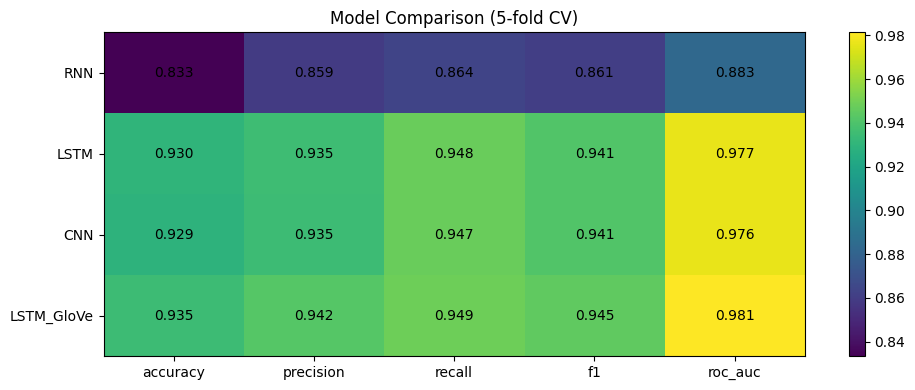

In [43]:
rnn = pd.DataFrame(RNN_scores, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], columns=['RNN']).T
lstm = pd.DataFrame(LSTM_scores, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], columns=['LSTM']).T
cnn = pd.DataFrame(CNN_scores, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], columns=['CNN']).T
lstm_glove = pd.DataFrame(LSTM_GloVe_scores, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], columns=['LSTM_GloVe']).T
all_models = pd.concat([rnn, lstm, cnn, lstm_glove])

heat_map(all_models)

# По результатам видно, что худшее качество показала модель RNN, при этом остальные модели показали примерно одинаковое качество. Также можно отметить и хорошее качество модели logreg в рамках baseline